In [10]:
import numpy as np
import bayesflow as bf
from pathlib import Path

from benchmark.examples.diffusion.simulators.rdm_4 import RDM


In [11]:
np.random.seed(2026)


In [12]:
simulators = [
    RDM(model="m0", keep_params=False),
    RDM(model="m1", keep_params=False),
    RDM(model="m2", keep_params=False),
    RDM(model="m3", keep_params=False),
]


In [13]:
# Each trial contains signed RT and condition: (batch_size, 384, 2).
adapter = (
    bf.adapters.Adapter()
    .as_set(["rt", "conditions"])
    .concatenate(["rt", "conditions"], into="summary_variables")
    .convert_dtype("float64", "float32")
    .rename("model_indices", "inference_variables")
)


In [14]:
workflow = bf.ModelComparisonWorkflow(
    simulator=simulators,
    adapter=adapter,
    summary_network=bf.networks.DeepSet(summary_dim=12),
    scoring_rules="cross_entropy",
    model_names=["M0", "M1", "M2", "M3"],
    initial_learning_rate=1e-3,
)


In [15]:
val_data = workflow.simulate(1000)

In [16]:
history = workflow.fit_online(epochs=200, num_batches_per_epoch=64, batch_size=256, validation_data=val_data)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 420ms/step - ScoringRuleNetwork/scoring_rule: 1.4258 - loss: 1.4258 - val_ScoringRuleNetwork/scoring_rule: 1.3565 - val_loss: 1.3565
Epoch 2/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 400ms/step - ScoringRuleNetwork/scoring_rule: 1.3608 - loss: 1.3608 - val_ScoringRuleNetwork/scoring_rule: 1.3333 - val_loss: 1.3333
Epoch 3/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 482ms/step - ScoringRuleNetwork/scoring_rule: 1.2182 - loss: 1.2182 - val_ScoringRuleNetwork/scoring_rule: 1.0283 - val_loss: 1.0283
Epoch 4/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 813ms/step - ScoringRuleNetwork/scoring_rule: 1.0315 - loss: 1.0315 - val_ScoringRuleNetwork/scoring_rule: 1.0376 - val_loss: 1.0376
Epoch 5/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 915ms/step - ScoringRuleNetwork/scoring_rule: 1.0030 - loss: 1.0030 - val_ScoringRuleNetwork/scoring_rule: 0.9465 - val_loss: 0.9465
Epoch 6/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 884ms/step - ScoringRuleNetwork/scoring_rule: 0.9348 - loss: 0.9348 - val_Sco

INFO:bayesflow:Training completed in 3.15 hours.


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Estimating completed in 4.17 seconds.


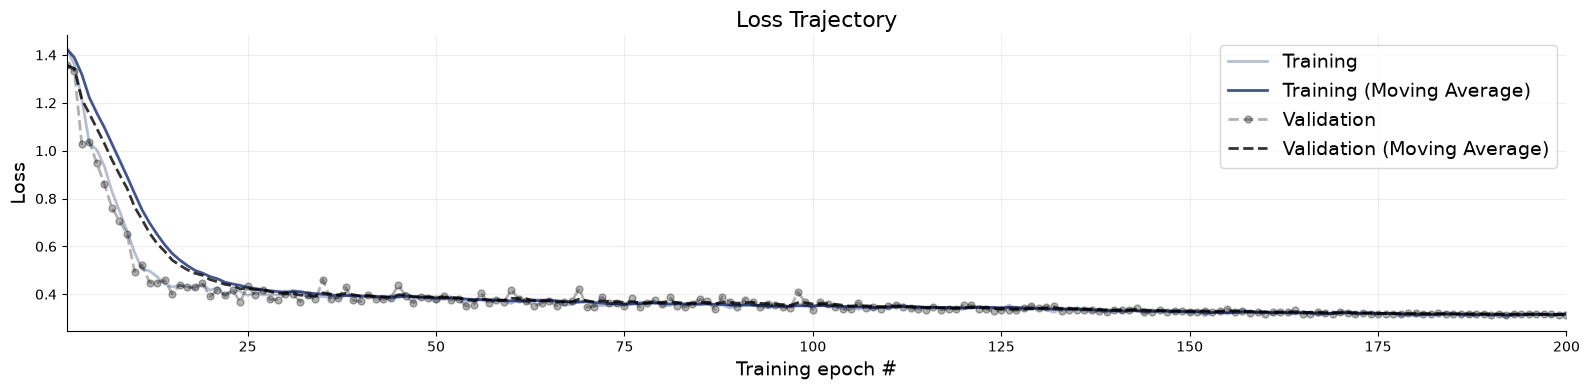

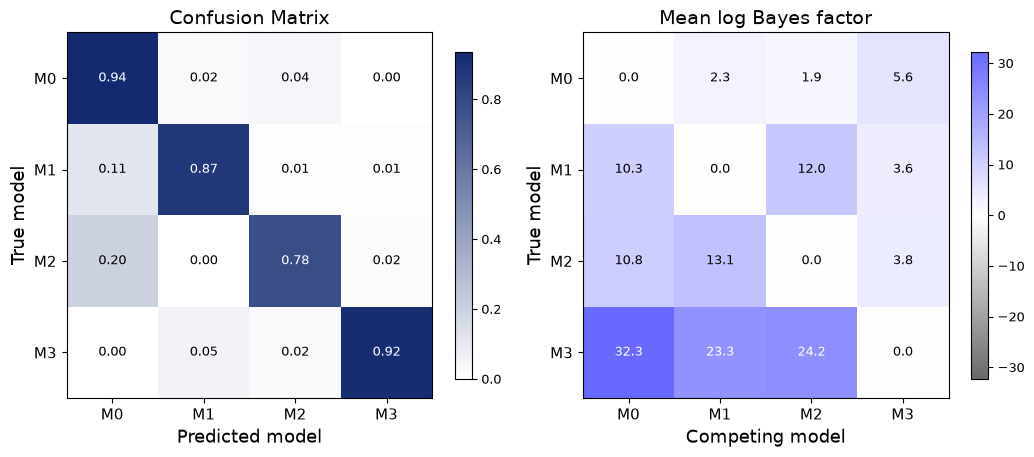

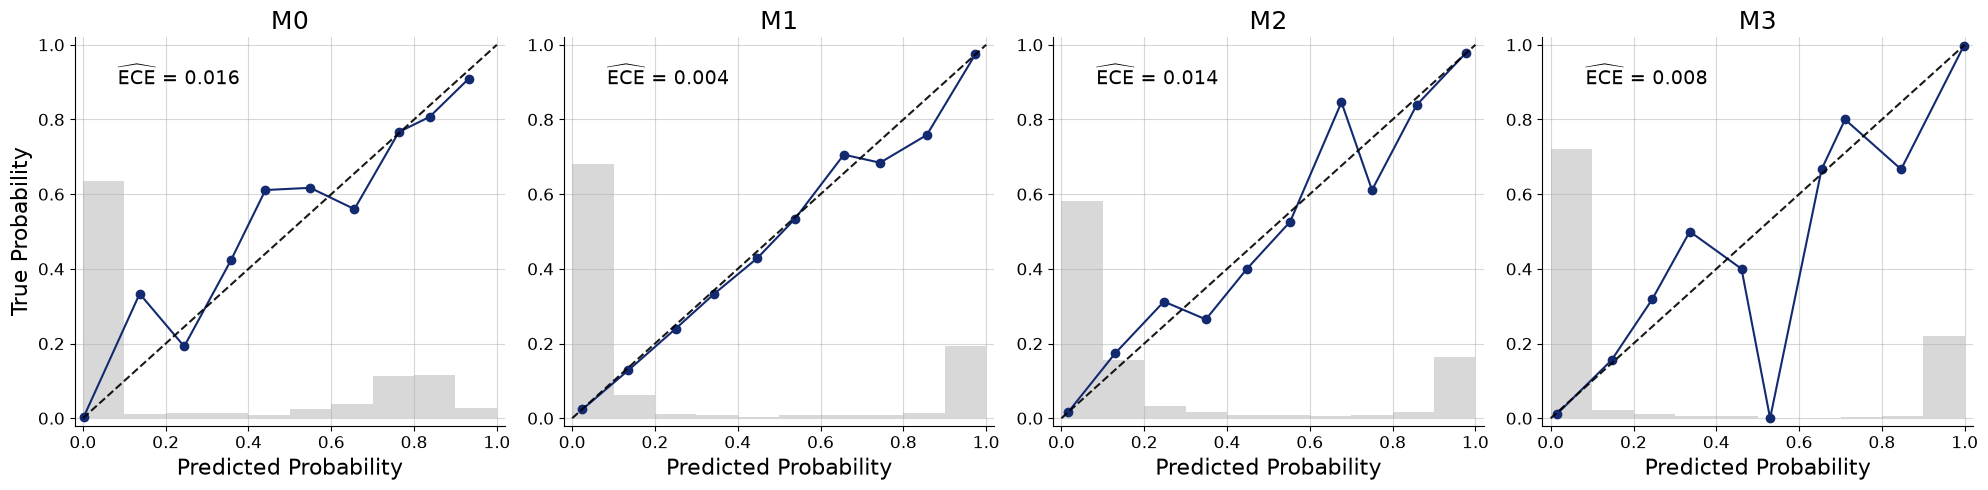

In [17]:
figures = workflow.plot_default_diagnostics(test_data=2000)


In [18]:
# Save the trained approximator
filepath = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/approximators/trained/direct/direct_cent.keras")
filepath.parent.mkdir(exist_ok=True)
workflow.approximator.save(filepath=filepath)


In [19]:
# Evaluate the saved checkpoint on the shared indirect benchmark.
from benchmark.examples.diffusion.analysis.direct_calibration import ensure_direct_pmp_thresholds
from benchmark.examples.diffusion.analysis.direct_diagnostics import ensure_direct_diagnostics

LOSS = "cross_entropy"
thresholds = ensure_direct_pmp_thresholds(LOSS, checkpoint=filepath)
diagnostics = ensure_direct_diagnostics(LOSS, checkpoint=filepath, indirect_tag="S4D")
print(f"Saved {len(thresholds)} threshold rows and {len(diagnostics)} observed diagnostic rows.")
print(filepath.parent.parent / "results" / "direct" / f"direct_{LOSS}")


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Calibrated cross_entropy on 400 saved diffusion datasets: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/direct/direct_cross_entropy/calibration/thresholds.csv


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Fitting direct_cross_entropy/m0 against the persisted shared raw reference bank


...

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.
INFO:absl:Epoch 1/250
 1/16 ━━━━━━━━━━━━━━━━━━━━ 1:53 8s/step - loss: 17.0273
 5/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 9.5296 
 8/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 5.7348
12/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.8039
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: -0.0295
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 6.0047 

INFO:absl:Epoch 2/250
 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: -0.2551
 5/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: -0.4562
 8/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: -1.4502
11/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: -1.9456
14/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: -2.3259
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: -1.2357

INFO:absl:Epoch 3/250
 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: -2.7171
 4/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: -2.6223
 8/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss:

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Saved 2176 observed diagnostic rows for cross_entropy
Saved 4 threshold rows and 2176 observed diagnostic rows.
/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/approximators/trained/results/direct/direct_cross_entropy
